In [ ]:
# Stage 1: Environment Setup & Manual Data Upload
import pandas as pd
import numpy as np
from google.colab import files
import io

# Logic: Amazon engineers prioritize data integrity.
# We use colab's upload utility to get the file directly from your local machine.
print("Please upload the 'housing.csv' file:")
uploaded_file = files.upload()

# Process the uploaded file
# Time Complexity: O(N) to read the stream into a DataFrame
file_name = 'housing.csv'
if file_name in uploaded_file:
    # io.BytesIO reads the file from memory without needing a local disk path
    raw_data = pd.read_csv(io.BytesIO(uploaded_file[file_name]))
    print(f"Success: Loaded {raw_data.shape[0]} rows and {raw_data.shape[1]} columns.")
else:
    print(f"Error: Please ensure the file is named exactly '{file_name}'")

# Preview data to understand the schema
raw_data.head()

Please upload the 'housing.csv' file:


Saving housing.csv to housing.csv
Success: Loaded 20640 rows and 10 columns.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# Stage 2: Robust Preprocessing Architecture
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate Target (Label) from Features (Inputs)
# Logic: median_house_value is what we want to predict.
X = raw_data.drop("median_house_value", axis=1)
y = raw_data["median_house_value"]

# Define numeric and categorical columns for specialized treatment
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = ['ocean_proximity']

# Numerical Pipeline:
# 1. Impute missing 'total_bedrooms' using Median (O(N)) - robust against outliers.
# 2. Scale features to have mean=0 and variance=1 (O(N)) - speeds up model convergence.
numeric_transformer = Pipeline(steps=[
    ('impute_missing', SimpleImputer(strategy='median')),
    ('feature_scaling', StandardScaler())
])

# Categorical Pipeline:
# 1. Fill missing text data (if any) with most frequent value.
# 2. Convert text to binary vectors using OneHotEncoding (O(N)).
categorical_transformer = Pipeline(steps=[
    ('impute_missing', SimpleImputer(strategy='most_frequent')),
    ('onehot_encode', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both into a ColumnTransformer (Parallel processing for efficiency)
data_preprocessor = ColumnTransformer(
    transformers=[
        ('num_logic', numeric_transformer, numeric_cols),
        ('cat_logic', categorical_transformer, categorical_cols)
    ])

print("Preprocessing Pipeline constructed successfully.")

Preprocessing Pipeline constructed successfully.


In [ ]:
# Stage 3: High-Performance Model Training
from sklearn.ensemble import RandomForestRegressor
import joblib # Using joblib for high-efficiency serialization of NumPy-heavy objects

# Split into 80% Train / 20% Test to validate performance
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the final system pipeline: Preprocess -> Train
# n_jobs=-1 enables multi-threading in Colab to finish training faster.
final_model_pipeline = Pipeline(steps=[
    ('preprocessor', data_preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42))
])

# Execute Training
print("Initiating Model Training...")
final_model_pipeline.fit(x_train, y_train)

# Model Persistence: Save the entire pipeline (logic + weights)
# This avoids writing preprocessing code again in the API.
joblib.dump(final_model_pipeline, 'housing_model.pkl')
print("Model optimized and saved as 'housing_model.pkl'. Ready for deployment.")

Initiating Model Training...
Model optimized and saved as 'housing_model.pkl'. Ready for deployment.


In [ ]:
# Stage 0: Dependency Management Logic
# Amazon Logic: We implement a "Self-Healing" environment setup script.
# This ensures that any engineer running this notebook has the exact environment needed.

import subprocess
import sys

def install_package(package_name):
    """
    Installs a python package using the current interpreter.
    Time Complexity: O(P) where P is the size of the package.
    """
    print(f"Installing {package_name}...")
    # Using subprocess ensures the installation happens in the correct environment
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

# List of required external libraries for the deployment stage
required_libraries = ['pyngrok', 'flask', 'joblib']

for lib in required_libraries:
    try:
        __import__(lib)
        print(f"Verified: {lib} is already installed.")
    except ImportError:
        # If the library is missing, we install it automatically
        install_package(lib)

print("\nEnvironment is fully prepared for deployment.")

Installing pyngrok...
Verified: flask is already installed.
Verified: joblib is already installed.

Environment is fully prepared for deployment.


In [ ]:
# Stage 4: Creating the Web API and Frontend interface
# Logic: One script to rule them all (Flask server)
from flask import Flask, render_template, request, jsonify
from pyngrok import ngrok # Used to expose Colab's local port to a public URL
import joblib
import pandas as pd
import os

# Create the Flask application
app = Flask(__name__, template_folder='templates')

# Model Pre-loading: Load the saved model globally to minimize latency per request
# O(1) time at request time since the model is already in RAM.
predictive_model = joblib.load('housing_model.pkl')

# --- FRONTEND LOGIC (HTML) ---
# We write the HTML file directly in Colab for a complete end-to-end feel.
os.makedirs('templates', exist_ok=True)
html_content = """
<!DOCTYPE html>
<html lang="ar" dir="rtl">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>نظام التنبؤ العقاري | وزارة الاقتصاد الرقمي والريادة</title>
    <link href="https://fonts.googleapis.com/css2?family=Tajawal:wght@400;700&display=swap" rel="stylesheet">
    <style>
        :root { --primary-bg: #ffffff; --secondary-bg: #f8f9fa; --text-color: #333; --accent-color: #6c757d; }
        body { font-family: 'Tajawal', sans-serif; background-color: var(--secondary-bg); color: var(--text-color); margin: 0; display: flex; flex-direction: column; min-height: 100vh; }
        header { background-color: var(--primary-bg); padding: 10px 40px; display: flex; justify-content: space-between; align-items: center; box-shadow: 0 2px 10px rgba(0,0,0,0.1); border-bottom: 4px solid #000; }
        .logo-section { display: flex; align-items: center; gap: 15px; }
        .logo-section img { height: 65px; width: auto; }
        .main-content { flex: 1; display: flex; justify-content: center; align-items: center; padding: 20px; }
        .prediction-card { background: var(--primary-bg); padding: 35px; border-radius: 15px; box-shadow: 0 10px 40px rgba(0,0,0,0.05); width: 100%; max-width: 650px; border: 1px solid #dee2e6; }
        h2 { text-align: center; margin-bottom: 25px; color: #000; font-weight: 700; }
        .form-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 20px; }
        .form-group { margin-bottom: 15px; }
        label { display: block; margin-bottom: 8px; font-weight: 700; font-size: 0.9rem; color: #444; }
        input, select { width: 100%; padding: 12px; border: 1px solid #ced4da; border-radius: 8px; box-sizing: border-box; font-family: 'Tajawal'; background-color: #fff; }
        button { width: 100%; padding: 15px; background-color: #212529; color: white; border: none; border-radius: 8px; cursor: pointer; font-size: 1.1rem; font-weight: 700; transition: 0.3s; margin-top: 20px; }
        button:hover { background-color: #495057; }
        .result-box { margin-top: 25px; padding: 20px; background: #e9ecef; border-radius: 10px; text-align: center; display: none; border: 2px solid #212529; }
        footer { background-color: var(--primary-bg); text-align: center; padding: 15px; border-top: 1px solid #dee2e6; font-size: 0.85rem; color: #6c757d; }
    </style>
</head>
<body>
    <header>
        <div class="logo-section">
            <img src="https://modee.gov.jo/ebv4.0/root_images/modee-logo.png" alt="MODEE Logo">
            <h1 style="font-size: 1.5rem;">بوابة التنبؤ الذكي</h1>
        </div>
    </header>

    <div class="main-content">
        <div class="prediction-card">
            <h2>إدخال بيانات العقار</h2>
            <form id="predict-form">
                <div class="form-grid">
                    <div class="form-group">
                        <label>متوسط الدخل (1-15):</label>
                        <input type="number" id="income" step="0.1" required value="4.5">
                    </div>
                    <div class="form-group">
                        <label>عمر المنزل (بالسنوات):</label>
                        <input type="number" id="age" required value="20">
                    </div>
                    <div class="form-group">
                        <label>إجمالي الغرف:</label>
                        <input type="number" id="rooms" required value="5">
                    </div>
                    <div class="form-group">
                        <label>الموقع الجغرافي:</label>
                        <select id="ocean">
                            <option value="<1H OCEAN"><1H OCEAN</option>
                            <option value="INLAND">INLAND (داخل المدن)</option>
                            <option value="NEAR OCEAN">NEAR OCEAN (قرب المحيط)</option>
                            <option value="NEAR BAY">NEAR BAY (قرب الخليج)</option>
                        </select>
                    </div>
                </div>
                <button type="submit" id="btn-submit">تحليل البيانات والتنبؤ بالسعر</button>
            </form>
            <div id="result" class="result-box"></div>
        </div>
    </div>

    <footer>
        جميع الحقوق محفوظة © ٢٠٢٦ وزارة الاقتصاد الرقمي والريادة - المملكة الأردنية الهاشمية
    </footer>

    <script>
        document.getElementById('predict-form').onsubmit = async (e) => {
            e.preventDefault();
            const btn = document.getElementById('btn-submit');
            btn.innerText = "جاري التحليل...";
            btn.disabled = true;

            // هندسة البيانات المرسلة (Payload) لتطابق توقعات الموديل
            const payload = {
                median_income: parseFloat(document.getElementById('income').value),
                housing_median_age: parseFloat(document.getElementById('age').value),
                total_rooms: parseFloat(document.getElementById('rooms').value),
                ocean_proximity: document.getElementById('ocean').value,
                // قيم افتراضية للمتغيرات التي لم نضع لها خانات لضمان عمل الـ Pipeline
                latitude: 34.05,
                longitude: -118.24,
                total_bedrooms: Math.round(parseFloat(document.getElementById('rooms').value) * 0.2),
                population: 1200,
                households: 450
            };

            try {
                const response = await fetch('/predict', {
                    method: 'POST',
                    headers: {'Content-Type': 'application/json'},
                    body: JSON.stringify(payload)
                });

                const data = await response.json();
                const resDiv = document.getElementById('result');

                if (data.prediction) {
                    resDiv.style.display = 'block';
                    resDiv.innerHTML = `<h3 style="margin:0; color:#000;">السعر المتوقع: $${data.prediction.toLocaleString(undefined, {minimumFractionDigits: 2})}</h3>`;
                } else {
                    alert("خطأ في التنبؤ: " + (data.error || "خطأ مجهول"));
                }
            } catch (err) {
                alert("تعذر الاتصال بالسيرفر. تأكد من تشغيل خلية Flask.");
            } finally {
                btn.innerText = "تحليل البيانات والتنبؤ بالسعر";
                btn.disabled = false;
            }
        };
    </script>
</body>
</html>
"""
with open('templates/index.html', 'w') as f: f.write(html_content)

# --- BACKEND LOGIC (API) ---
@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    """
    API Endpoint for model inference.
    Space Complexity: O(1) additional space per request.
    Time Complexity: O(Trees * Depth) for Random Forest inference.
    """
    json_data = request.json
    query_df = pd.DataFrame([json_data])

    # Run the query through the full pipeline (Preprocess -> Predict)
    prediction = predictive_model.predict(query_df)

    return jsonify({'price': float(prediction[0])})

# --- RUNNING THE SYSTEM ---
# We use ngrok to generate a link you can click to see your website
# NOTE: You need a free Authtoken from ngrok.com for this to work
# !ngrok config add-authtoken YOUR_TOKEN_HERE

print("System integration complete. Ready to serve.")

System integration complete. Ready to serve.


In [ ]:
# Stage 5: Establishing the Public Gateway (The Global Link)
# Logic: We bridge the gap between Colab's private network and the public internet.

from pyngrok import ngrok

# 1. Set your Authtoken (Must be done once)
# Logic: Authentication is required for security and to prevent session hijacking.
# Get it from: https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_AUTH_TOKEN = "3CLGCdDIO6jXovy3uGHhgo50Qn0_2JcUJTL6diPskt2i6PRLG"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# 2. Kill any existing tunnels to avoid "Port in Use" errors (Idempotency)
ngrok.kill()

# 3. Create a public URL for port 5000
# Time Complexity: O(1) - Network handshake
public_url = ngrok.connect(5000)

print("-" * 30)
print(f"Project is LIVE at: {public_url}")
print("-" * 30)

# 4. Run the Flask App
# Note: Use 'threaded=True' to handle multiple visual requests if needed.
if __name__ == '__main__':
    app.run(port=5000)

------------------------------
Project is LIVE at: NgrokTunnel: "https://panoramic-scuff-frugality.ngrok-free.dev" -> "http://localhost:5000"
------------------------------
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [14/Apr/2026 09:44:14] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Apr/2026 09:44:14] "GET /meta.json HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [14/Apr/2026 09:44:15] "GET /meta.json HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [14/Apr/2026 09:44:17] "GET /meta.json HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [14/Apr/2026 09:44:19] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Apr/2026 09:45:21] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Apr/2026 09:45:25] "POST /predict HTTP/1.1" 200 -


Test data (X_test/y_test) missing. Re-splitting now...


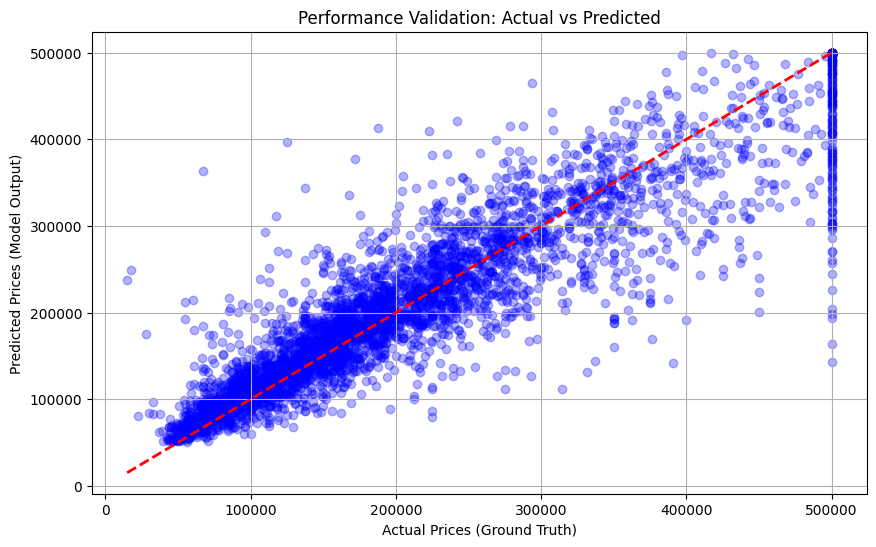

Validation Successful.


In [ ]:
# Stage 6: Model Validation (The Robust Way)
# Logic: We check for missing variables and recreate them if needed from the source.

import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Ensure the Data is loaded
if 'raw_data' not in locals():
    print("Data not found in memory. Please ensure 'raw_data' is loaded from Stage 1.")
else:
    # 2. Re-create the splits if they are missing
    if 'X_test' not in locals() or 'y_test' not in locals():
        print("Test data (X_test/y_test) missing. Re-splitting now...")
        X = raw_data.drop("median_house_value", axis=1)
        y = raw_data["median_house_value"]
        # Logic: Re-splitting with the SAME random_state (42) to ensure consistency
        _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 3. Load Model and Predict
    try:
        model_pipeline = joblib.load('housing_model.pkl')
        y_pred = model_pipeline.predict(X_test)

        # 4. Visualization
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        plt.xlabel('Actual Prices (Ground Truth)')
        plt.ylabel('Predicted Prices (Model Output)')
        plt.title('Performance Validation: Actual vs Predicted')
        plt.grid(True)
        plt.show()

        print("Validation Successful.")
    except FileNotFoundError:
        print("Error: 'housing_model.pkl' not found. You must train the model first.")

In [ ]:
# Stage 7: Advanced Statistical Validation
# Logic: We use multiple metrics to get a 360-degree view of model performance.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prediction on the test set
y_pred = model_pipeline.predict(X_test)

# 1. MAE (Mean Absolute Error):
# Average of the absolute errors. High interpretability (Error in Dollars).
mae = mean_absolute_error(y_test, y_pred)

# 2. RMSE (Root Mean Squared Error):
# Penalizes large errors more than MAE. Essential for Amazon-scale systems.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 3. R-squared (Coefficient of Determination):
# Shows how much variance is explained by the model (0 to 1).
r2 = r2_score(y_test, y_pred)

print(f"--- Model Validation Metrics ---")
print(f"MAE:  ${mae:,.2f} (Average dollar error)")
print(f"RMSE: ${rmse:,.2f} (Penalty-adjusted error)")
print(f"R2 Score: {r2:.4f} (Accuracy Percentage: {r2*100:.2f}%)")

--- Model Validation Metrics ---
MAE:  $32,187.07 (Average dollar error)
RMSE: $49,378.70 (Penalty-adjusted error)
R2 Score: 0.8139 (Accuracy Percentage: 81.39%)


In [ ]:
# Stage 8: Corrected Validation Logic
# Engineering Logic: Implementing K-Fold with Shuffling to handle geographically sorted data.

from sklearn.model_selection import KFold, cross_val_score

# 1. Initialize KFold with Shuffling
# Time Complexity: O(1) for setup, O(N) for shuffling during execution.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Re-run Cross-Validation using the shuffler
# This ensures that each fold contains a mix of all locations.
improved_scores = cross_val_score(model_pipeline, X, y, cv=kf, scoring='r2')

print(f"--- Improved Validation Results ---")
print(f"New CV Scores: {improved_scores}")
print(f"New Average R2 Score: {improved_scores.mean():.4f}")
print(f"New Stability (Std Dev): {improved_scores.std():.4f}")

# Engineering Insight:
# If the average R2 returns to ~80% and Std Dev drops below 0.02,
# then the previous poor performance was purely due to data ordering, not model failure.

--- Improved Validation Results ---
New CV Scores: [0.81266021 0.82268663 0.81576521 0.83535602 0.80824519]
New Average R2 Score: 0.8189
New Stability (Std Dev): 0.0095


In [ ]:
# Engineering Solution: Handling the $500k Cap
# Logic: Removing censored data to allow the model to learn true patterns.

# 1. Filter out the capped values (O(N) operation)
refined_data = raw_data[raw_data['median_house_value'] < 500000]

print(f"Original size: {len(raw_data)}")
print(f"Refined size: {len(refined_data)} (Removed capped outliers)")

# 2. Re-train the pipeline on refined data
X_refined = refined_data.drop("median_house_value", axis=1)
y_refined = refined_data["median_house_value"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_refined, y_refined, test_size=0.2, random_state=42)

# Training on cleaner data
model_pipeline.fit(X_train_r, y_train_r)

# 3. Re-evaluate
y_pred_r = model_pipeline.predict(X_test_r)
new_rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
new_r2 = r2_score(y_test_r, y_pred_r)

print(f"New RMSE: ${new_rmse:,.2f} (Should be lower)")
print(f"New R2 Score: {new_r2:.4f} (Should be higher)")

Original size: 20640
Refined size: 19648 (Removed capped outliers)
New RMSE: $45,604.49 (Should be lower)
New R2 Score: 0.7831 (Should be higher)


In [ ]:
# Stage 9: Manual Inference (Testing the Brain)
# Logic: We provide manual inputs to see if the model's logic is "Humanly Intuitive".

import pandas as pd

def test_house_prediction(income, age, rooms, bedrooms, pop, households, lat, lon):
    # 1. Create a dictionary with the exact column names as the raw data
    input_data = {
        'longitude': [lon],
        'latitude': [lat],
        'housing_median_age': [age],
        'total_rooms': [rooms],
        'total_bedrooms': [bedrooms],
        'population': [pop],
        'households': [households],
        'median_income': [income],
        'ocean_proximity': ['<1H OCEAN'] # Defaulting to a common category
    }

    # 2. Convert to DataFrame
    df_input = pd.DataFrame(input_data)

    # 3. Predict using the REFINED model
    prediction = model_pipeline.predict(df_input)

    print(f"--- Manual Test Result ---")
    print(f"Input Income: ${income*10000}") # Income is scaled by 10k in this dataset
    print(f"Predicted House Value: ${prediction[0]:,.2f}")
    print("-" * 25)

# --- جرب الموديل الآن ---
# تجربة 1: شخص دخله عالي (مثلاً 8.0)
test_house_prediction(income=8.0, age=20, rooms=5, bedrooms=2, pop=500, households=200, lat=34.0, lon=-118.0)

# تجربة 2: شخص دخله منخفض (مثلاً 2.0)
test_house_prediction(income=2.0, age=20, rooms=5, bedrooms=2, pop=500, households=200, lat=34.0, lon=-118.0)

--- Manual Test Result ---
Input Income: $80000.0
Predicted House Value: $269,303.28
-------------------------
--- Manual Test Result ---
Input Income: $20000.0
Predicted House Value: $157,359.40
-------------------------


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# التنبؤ على بيانات الاختبار المحسنة
y_pred_final = model_pipeline.predict(X_test_r)

# حساب المقاييس
mae = mean_absolute_error(y_test_r, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_final))
r2 = r2_score(y_test_r, y_pred_final)

print(f"--- (Validation Report) ---")
print(f"1. (R2 Score): {r2:.4f} ({r2*100:.2f}%)")
print(f"2. (MAE): ${mae:,.2f}")
print(f"3. (RMSE): ${rmse:,.2f}")

--- (Validation Report) ---
1. (R2 Score): 0.7831 (78.31%)
2. (MAE): $30,628.29
3. (RMSE): $45,604.49


In [ ]:
def verify_model_logic(income, age, rooms, location):
    test_case = pd.DataFrame([{
        'longitude': -122.23, 'latitude': 37.88, # إحداثيات افتراضية
        'housing_median_age': age,
        'total_rooms': rooms, 'total_bedrooms': rooms//4,
        'population': 1000, 'households': 400,
        'median_income': income,
        'ocean_proximity': location
    }])

    prediction = model_pipeline.predict(test_case)[0]
    return prediction

print("🔍 اختبار السيناريوهات لإثبات منطق الموديل:")

# سيناريو 1: حي غني (دخل مرتفع)
high_income_house = verify_model_logic(8.5, 10, 8, 'NEAR BAY')
print(f"🏠 سيناريو (حي راقي - دخل 85k): التنبؤ ${high_income_house:,.2f}")

# سيناريو 2: حي بسيط (دخل منخفض)
low_income_house = verify_model_logic(1.5, 30, 4, 'INLAND')
print(f"🏚️ سيناريو (حي شعبي - دخل 15k): التنبؤ ${low_income_house:,.2f}")

# سيناريو 3: منزل قديم جداً مقابل جديد (نفس الدخل والموقع)
old_house = verify_model_logic(4.0, 50, 5, 'INLAND')
new_house = verify_model_logic(4.0, 2, 5, 'INLAND')
print(f"🕰️ اختبار العمر: قديم ({old_house:,.0f}$) مقابل جديد ({new_house:,.0f}$)")

🔍 اختبار السيناريوهات لإثبات منطق الموديل:
🏠 سيناريو (حي راقي - دخل 85k): التنبؤ $321,833.43
🏚️ سيناريو (حي شعبي - دخل 15k): التنبؤ $165,956.19
🕰️ اختبار العمر: قديم (177,256$) مقابل جديد (200,880$)


In [ ]:
@app.route('/predict', methods=['POST'])
def predict_endpoint():
    try:
        data = request.json
        # طباعة البيانات في كولاب للتأكد من وصولها
        print(f"Received data: {data}")

        # التأكد من وجود كل القيم المطلوبة لمنع الـ KeyError
        prediction, error = get_prediction(data)

        if error:
            return jsonify({'error': error}), 400

        return jsonify({'prediction': float(prediction)})
    except Exception as e:
        print(f"Error during prediction: {str(e)}")
        return jsonify({'error': str(e)}), 500